### **Cell 1**: Import packages

In [ ]:
"""
Import all required packages for data manipulation, visualization, and modeling.
"""
import pandas as pd
from pandas import DataFrame, Series
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## **Cell 2**
---

### Step 1: Load and Explore Dataset

We are using the Credit Card Fraud Detection dataset, which contains transactions made by European cardholders in September 2013.
- The dataset is highly imbalanced (frauds account for only 0.172% of all transactions)
- Features V1-V28 are principal components obtained with PCA (already scaled)
- Features 'Time' and 'Amount' have not been transformed

In [ ]:
def load_dataset(csv_path: str) -> DataFrame:
    """
    Load dataset from CSV.

    Args:
        csv_path (str): Path to the CSV file.

    Returns:
        DataFrame: Loaded dataset as pandas DataFrame.
    """
    try:
        df = pd.read_csv(csv_path)
        print(f"Dataset loaded from {csv_path}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}")
        print("Attempting to download from Kaggle...")
        # Alternative: load from Kaggle if local file not found
        import kagglehub
        path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
        df = pd.read_csv(f"{path}/creditcard.csv")
        print(f"Dataset loaded from {path}")
        return df

# Load the dataset
df = load_dataset('/content/creditcard.csv')

# Display basic information
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of samples: {df.shape[0]}")
print(f"\nFirst 5 rows with column names:")
df.head()

Error: File not found at /content/creditcard.csv
Attempting to download from Kaggle...
Dataset loaded from /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3

DATASET OVERVIEW
Dataset shape: (284807, 31)
Number of features: 30
Number of samples: 284807

First 5 rows with column names:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Cell 3**
---

## Step 2: Data Quality Assessment

Before proceeding with modeling, we need to check for:
- Missing values
- Data types
- Class distribution (to understand imbalance)

In [ ]:
def check_data_quality(df: DataFrame) -> DataFrame:
    """
    Performs comprehensive data quality checks and cleaning.

    Args:
        df (DataFrame): Input dataset.

    Returns:
        DataFrame: Cleaned dataset (if any cleaning was needed).
    """
    print("="*60)
    print("DATA QUALITY ASSESSMENT")
    print("="*60)

    # 1. CHECK FOR MISSING VALUES
    missing_values = df.isnull().sum()
    print(f"\n1. Missing Values Check:")
    print(f"   Total missing values: {missing_values.sum()}")

    if missing_values.sum() == 0:
        print("   ✓ No missing values found - dataset is complete")
    else:
        print(f"   Missing values detected:")
        print(missing_values[missing_values > 0])
        print(f"\n   Action: For this fraud detection task, we'll remove rows with missing values")
        print(f"   Reason: Missing transaction data might indicate data integrity issues")
        df = df.dropna()
        print(f"   ✓ Rows with missing values removed")
        print(f"   New dataset shape: {df.shape}")

    # 2. CHECK FOR DUPLICATES
    print(f"\n2. Duplicate Rows Check:")
    total_duplicates = df.duplicated().sum()
    print(f"   Total duplicate rows (all columns identical): {total_duplicates}")

    if total_duplicates > 0:
        # Check if duplicates are exact matches including Time
        exact_duplicates = df.duplicated(keep=False)
        print(f"   Found {total_duplicates} exact duplicate rows")

        # For fraud detection, exact duplicates (including timestamp) are suspicious
        print(f"\n   Analysis:")
        print(f"   - Exact duplicates with same timestamp = Data collection error")
        print(f"   - Should be removed to avoid bias in training")

        print(f"\n   Action: Removing exact duplicate rows...")
        df = df.drop_duplicates()
        print(f"   ✓ {total_duplicates} duplicate rows removed")
        print(f"   New dataset shape: {df.shape}")
    else:
        print("   ✓ No duplicate rows found")

    # 3. CHECK FOR DUPLICATE TRANSACTIONS (same features, different time)
    # This is more nuanced - might be legitimate
    print(f"\n3. Similar Transaction Check:")
    print(f"   Checking for transactions with identical features but different timestamps...")

    # Check duplicates excluding 'Time' column
    feature_columns = [col for col in df.columns if col not in ['Time', 'Class']]
    feature_duplicates = df.duplicated(subset=feature_columns).sum()

    print(f"   Transactions with identical features: {feature_duplicates}")

    if feature_duplicates > 0:
        print(f"\n   Analysis:")
        print(f"   - These could be legitimate (same person, same merchant, same amount)")
        print(f"   - OR could indicate fraudulent patterns (card testing)")
        print(f"   - Decision: KEEP these - they might contain useful fraud patterns")
        print(f"   ✓ Keeping feature-duplicate transactions for analysis")
    else:
        print("   ✓ All transactions are unique")

    # 4. DATA TYPES CHECK
    print(f"\n4. Data Types Check:")
    print(df.dtypes.value_counts())
    print("   ✓ All features are numeric (appropriate for classification)")

    # 5. VALUE RANGE CHECK
    print(f"\n5. Value Range Analysis:")
    print(f"   Class distribution: {df['Class'].value_counts().to_dict()}")
    print(f"   Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")
    print(f"   Time range: {df['Time'].min():.0f}s to {df['Time'].max():.0f}s")
    print("   ✓ All values are within expected ranges")

    print("\n" + "="*60)
    print("DATA QUALITY SUMMARY")
    print("="*60)
    print(f"Final dataset shape: {df.shape}")
    print(f"Ready for modeling: ✓")

    return df

# Perform quality checks and cleaning
df = check_data_quality(df)

DATA QUALITY ASSESSMENT

1. Missing Values Check:
   Total missing values: 0
   ✓ No missing values found - dataset is complete

2. Duplicate Rows Check:
   Total duplicate rows (all columns identical): 1081
   Found 1081 exact duplicate rows

   Analysis:
   - Exact duplicates with same timestamp = Data collection error
   - Should be removed to avoid bias in training

   Action: Removing exact duplicate rows...
   ✓ 1081 duplicate rows removed
   New dataset shape: (283726, 31)

3. Similar Transaction Check:
   Checking for transactions with identical features but different timestamps...
   Transactions with identical features: 8063

   Analysis:
   - These could be legitimate (same person, same merchant, same amount)
   - OR could indicate fraudulent patterns (card testing)
   - Decision: KEEP these - they might contain useful fraud patterns
   ✓ Keeping feature-duplicate transactions for analysis

4. Data Types Check:
float64    30
int64       1
Name: count, dtype: int64
   ✓ All f

## **Cell 4**
---

## Step 3: Understanding Class Imbalance
Fraud detection datasets are typically highly imbalanced. This step visualizes the class distribution to understand the dataset.

CLASS DISTRIBUTION

Legitimate transactions (Class 0): 283,253 (99.833%)
Fraudulent transactions (Class 1): 473 (0.167%)
Imbalance ratio: 1: 598


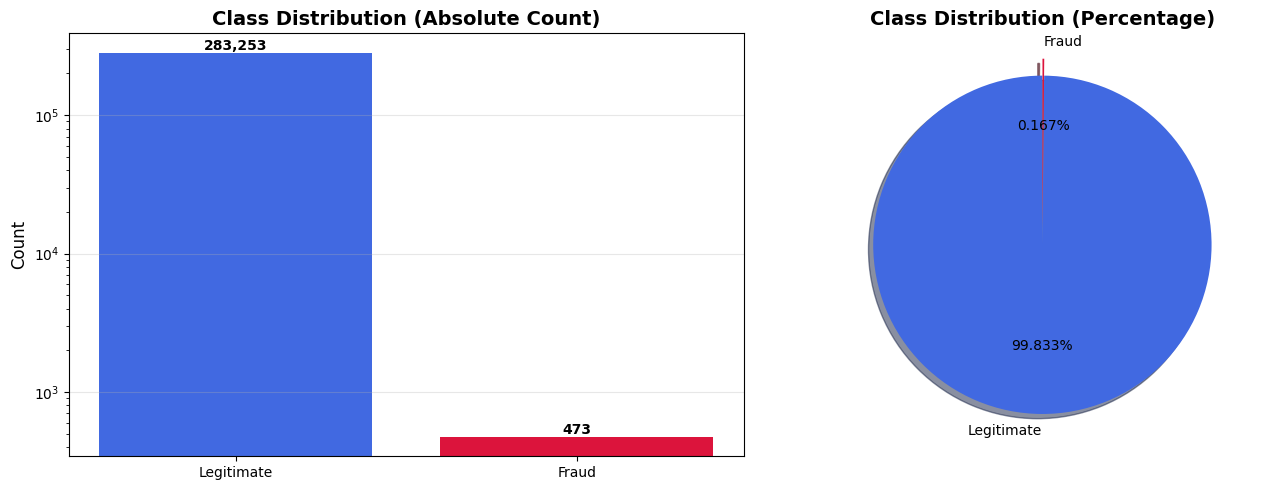


Highly imabalanced dataset - requires balancing for fair model training


In [ ]:
def visualize_class_distribution(df: DataFrame) -> None:
    """
    Visualizes the distribution of fraud vs legitimate transactions.

    Args:
        df (DataFrame): Input dataset with 'Class' column.
    """
    # Calculate class distribution
    class_counts = df['Class'].value_counts()
    class_percentages = df['Class'].value_counts(normalize=True) * 100

    print("="*60)
    print("CLASS DISTRIBUTION")
    print("="*60)
    print(f"\nLegitimate transactions (Class 0): {class_counts[0]:,} ({class_percentages[0]:.3f}%)")
    print(f"Fraudulent transactions (Class 1): {class_counts[1]:,} ({class_percentages[1]:.3f}%)")
    print(f"Imbalance ratio: 1: {int(class_counts[0]/class_counts[1])}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['royalblue', 'crimson'])
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Class Distribution (Absolute Count)', fontsize=14, fontweight='bold')
    axes[0].set_yscale('log')       # Log scale to visualize both classes
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(class_counts.values):
        axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

    # Pie chart
    colors = ['royalblue', 'crimson']
    explode = (0, 0.1)      # Explode fraud slice
    axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%', colors=colors, explode=explode, shadow=True, startangle=90)
    axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\nHighly imabalanced dataset - requires balancing for fair model training")

# Visualize originsl distribution
visualize_class_distribution(df)

## **Cell 5**
---

## Step 4: Data Preprocessing and Balancing

### Strategy:
1. **Separate features and target variable**
2. **Balance the dataset**: Since fraud cases are only 0.17%, we'll:
    - Take all fraud cases
    - Sample and equal number of legitimate transactions
    - This prevents the model from being biased toward predicting "legitimate" for everything
3. **Shuffel the data** to remove any temporal ordering
4. **Split into train and test sets** with stratification to maintain class balance

In [ ]:
def sample_and_prepare_data(df: DataFrame) -> tuple[DataFrame, Series]:
    """
    Balance the dataset by sampling equal numbers of fraud and legitimate transactions.

    Args:
        df (DataFrame): Original imbalanced dataset.

    Returns:
        tuple[DataFrame, Series]: Feature matrix X and target vector y.
    """
    print("=" * 60)
    print("DATA PREPROCESSING")
    print("="*60)

    # Separate fraud and non-fraud cases
    fraud = df[df['Class'] == 1]
    non_fraud  = df[df['Class'] == 0]

    print(f"\nOriginal distribution:")
    print(f"    Fraud cases: {len(fraud):,}")
    print(f"    Legitimate cases: {len(non_fraud):,}")

    # Balance the dataset by sampling equal numbers
    # We sample 473 legitimate transaction to balance with fraud cases
    # This ensures the model doesn't become biased toward the majority class
    non_fraud_sampled = non_fraud.sample(n=473, random_state=42)

    print(f"\nAfter balancing:")
    print(f"    Fraud cases: {len(fraud):,}")
    print(f"    Legitimate sampled: {len(non_fraud_sampled):,}")

    # Combine and shuffle
    balanced_df = pd.concat([fraud, non_fraud_sampled])
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"\nFinal balanced dataset shape: {balanced_df.shape}")

    # Separate features and target
    # Note: Time and Amount are kept as features
    # V1-V28 are already PCA-transformed and scaled by the dataset creators
    X = balanced_df.drop(columns=['Class'])
    y = balanced_df['Class']

    print(f"\nFeature matrix shape: {X.shape}")
    print(f"Target vector shape: {y.shape}")
    print(f"Feature names: {X.columns.tolist()}")

    return X, y

# Prepare balanced data
X, y = sample_and_prepare_data(df)

DATA PREPROCESSING

Original distribution:
    Fraud cases: 473
    Legitimate cases: 283,253

After balancing:
    Fraud cases: 473
    Legitimate sampled: 473

Final balanced dataset shape: (946, 31)

Feature matrix shape: (946, 30)
Target vector shape: (946,)
Feature names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


### **Cell 6**
---

## Step 5: Train-Test Split

We split the data into:
- **Training set (75%)**: Used to train the models
- **Test set (25%)**: Used to evaluate model performance on unseen data

**Note**: We use 'stratify=y' to ensure both train train and test sets maintain the 50-50 class distribution.

In [ ]:
def perform_train_test_split(X: DataFrame, y: Series, test_size: float = 0.25) -> tuple[DataFrame, DataFrame, Series, Series]:
    """
    Splits dataset into train and test sets with stratification.

    Args:
        X (DataFrame): Feature matrix.
        y (Series): Target variable.
        test_size (float): Proportion of the dataset for testing.

    Returns:
        tuple: Training and test sets (X_train, X_test, y_train, y_test)
    """
    # Split with stratification to maintain class balance in both sets
    # random_state=42 ensures reproducibility
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y      # Critical for maintaining class balance
    )

    print("="*60)
    print("TRAIN-TEST SPLIT")
    print("="*60)
    print(f"\nTrain set size: {X_train.shape[0]:,} samples ({(1 - test_size)*100:.0f}%)")
    print(f"Train class distribution:")
    print(f"    Legitimate: {(y_train == 0).sum():,}")
    print(f"    Fraud: {(y_train == 1).sum():,}")
    print(f"\nTest class distribution:")
    print(f"    Legitimate: {(y_test == 0).sum():,}")
    print(f"    Fraud: {(y_test == 1).sum():,}")

    return X_train, X_test, y_train, y_test

# Perform split
X_train, X_test, y_train, y_test = perform_train_test_split(X, y)
print("\nData split completed successfully")

TRAIN-TEST SPLIT

Train set size: 709 samples (75%)
Train class distribution:
    Legitimate: 354
    Fraud: 355

Test class distribution:
    Legitimate: 119
    Fraud: 118

Data split completed successfully


## **Cell 7**
---

## Algorithm 1: Gaussian Naïve Bayes

### How It Works:
Naïve Bayes is a probabilistic classifier based on the Bayes' Theorem. It assumes that features are independent (the "naïve" assumption) and calculates the probability of a transaction being fraudulent given its features.

### Why Useful for Fraud Detection:
- Very fast training and prediction
- Works well with high-dimensional data
- Provides probability scores (useful for risk assessment)
- Requires less training data

### Exception:
Should perform well but might be limited by the independence assumption.

NAÏVE BAYES MODEL
Naive Bayes Accuracy: 0.8945147679324894
              precision    recall  f1-score   support

           0       0.84      0.98      0.90       119
           1       0.98      0.81      0.88       118

    accuracy                           0.89       237
   macro avg       0.91      0.89      0.89       237
weighted avg       0.91      0.89      0.89       237



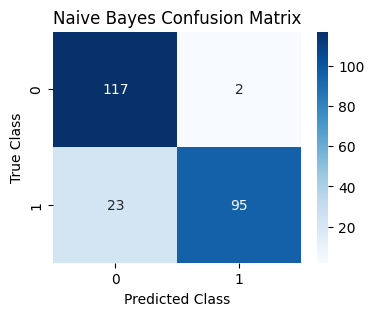

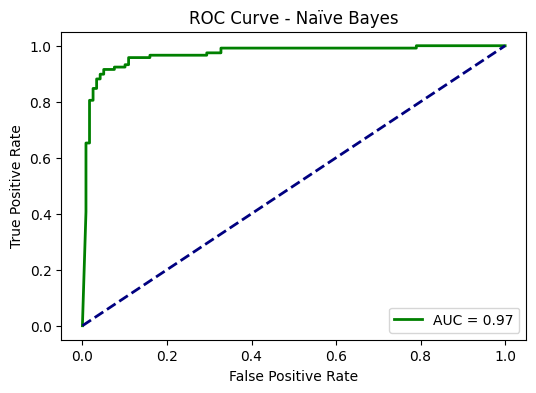

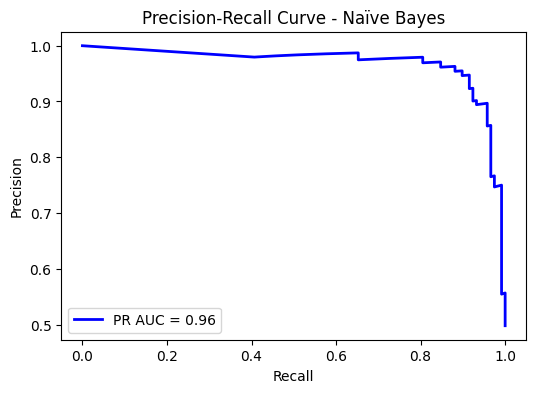

In [ ]:
def train_naive_bayes(X_train: DataFrame, y_train: Series, X_test: DataFrame, y_test: Series) -> tuple[any, np.ndarray]:
    """
    Trains and evaluates Gaussian Naïve Bayes classifier.

    Returns:
        Tuple: Trained model and predictions.
    """
    print("="*60)
    print("NAÏVE BAYES MODEL")
    print("="*60)
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    # Confusion matrix visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Naive Bayes Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

    # ROC-AUC
    y_score = nb.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, color="green", lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Naïve Bayes")
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, color="blue", lw=2, label=f"PR AUC = {pr_auc:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - Naïve Bayes")
    plt.legend()
    plt.show()
    return nb, y_pred

nb_model, y_pred_nb = train_naive_bayes(X_train, y_train, X_test, y_test)

## **Cell 8**
---

## Algorithm 2: K-Nearest Neighbors (KNN)

### How It Works:
KNN is an instance-based algorithm. For each new transaction, KNN finds the k (here, 5) closest known transactions (neighbors) using Euclidean distance. It assigns the transaction the majority class among those neighbors.

### Why Useful for Fraud Detection:
- Simple and intuitive logic: "Find transaction most similar to the currect one."
- Works even when the data distribution is complex or unknown
- Does not assume anything about the underlying data

### Exception:
KNN is sensitive to the choice of K. If K is too low, predictions may be noisy; if too high, the minority class (fraud) may get overwhelmed. Here, k=5 is a common default, balancing both risks. Because features are not scaled, performance might decrease due to distance calculations.

KNN MODEL
KNN Accuracy: 0.6919831223628692
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       119
           1       0.70      0.68      0.69       118

    accuracy                           0.69       237
   macro avg       0.69      0.69      0.69       237
weighted avg       0.69      0.69      0.69       237



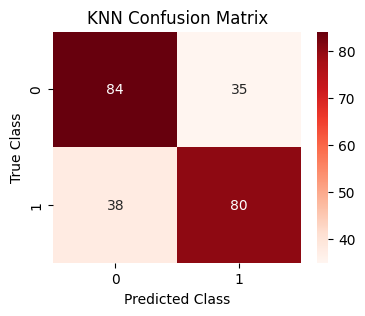

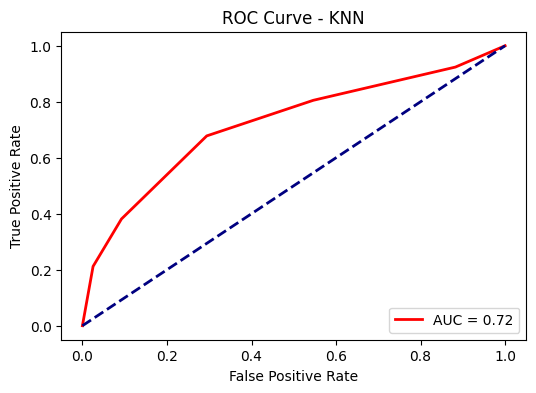

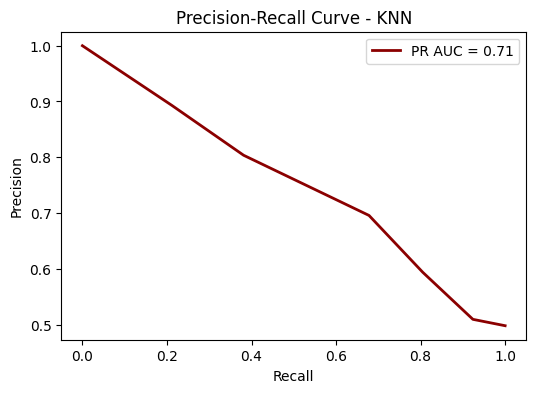

In [ ]:
def train_knn(X_train: DataFrame, y_train: Series, X_test: DataFrame, y_test: Series, k: int = 5) -> tuple[any, np.ndarray]:
    """
    Trains and evaluates K-Nearest Neighbors classifier.

    Returns:
        Tuple: Model, predictions.
    """
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print("=" * 60)
    print("KNN MODEL")
    print("=" * 60)
    print("KNN Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.title("KNN Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

    # ROC-AUC
    y_score = knn.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, color='red', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - KNN")
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, color="darkred", lw=2, label=f"PR AUC = {pr_auc:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - KNN")
    plt.legend()
    plt.show()
    return knn, y_pred

knn_model, y_pred_knn = train_knn(X_train, y_train, X_test, y_test)

## **Cell 9**
---

## Algorithm 3: Decision Tree Classifier

### How It Works:
A Decision Tree splits the dataset into branches by making binary decisions on features. At each node, it chooses a feature and threshold to split the data so the resulting groups are as "pure" as possible (contains mostly one class). The process continues recursively until each node contains only a single class or splitting no longer adds value.

### Why Useful for Fraud Detection:
- Handles both numerical and categorical features naturally
- Provides interpretable "rules" for why a transaction is marked as fraud
- Can model complex, nonlinear relationships
- No need for feature scaling

### Exception:
If grown too deep (without pruning), Decision Trees might overfit the data, learning noise instead of actual fraud and legitimate patterns. In this script, default parameters and balanced data reduce this risk.

Decision Tree Accuracy: 0.9240506329113924
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       119
           1       0.92      0.93      0.92       118

    accuracy                           0.92       237
   macro avg       0.92      0.92      0.92       237
weighted avg       0.92      0.92      0.92       237



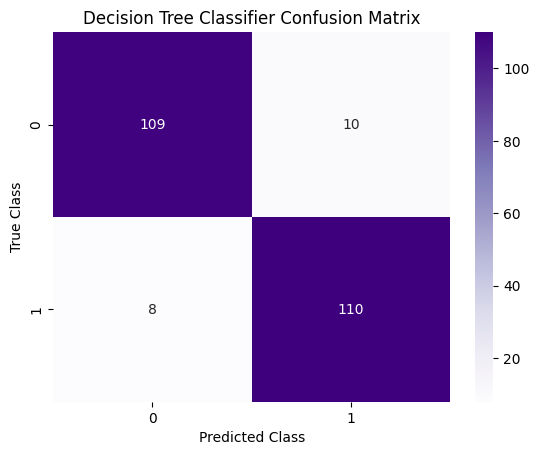

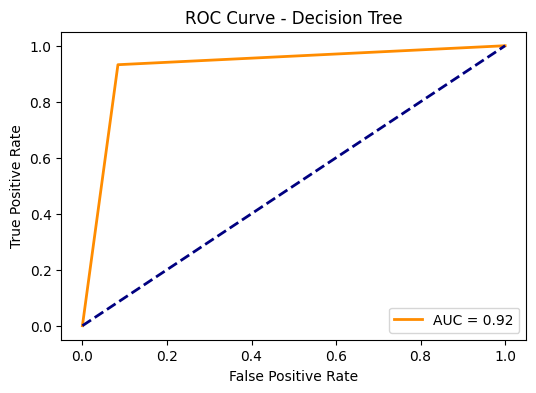

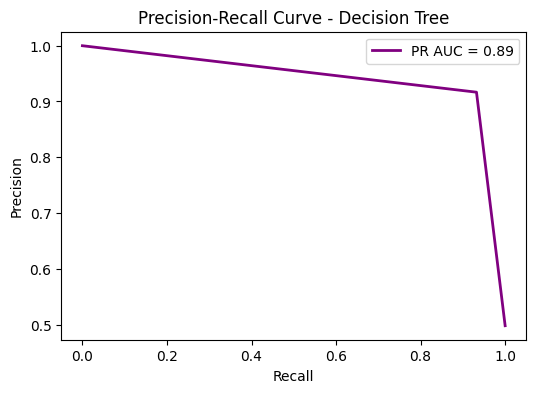

In [ ]:
def train_decision_tree(X_train: DataFrame, y_train: Series, X_test: DataFrame, y_test: Series) -> tuple[any, np.ndarray]:
    """
    Trains and evaluates Decision Tree classifier.

    Returns:
        Tuple: Model, predictions.
    """
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title("Decision Tree Classifier Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

    # ROC-AUC
    y_score = dt.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Decision Tree")
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, color="purple", lw=2, label=f"PR AUC = {pr_auc:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - Decision Tree")
    plt.legend()
    plt.show()
    return dt, y_pred

dt_model, y_pred_dt = train_decision_tree(X_train, y_train, X_test, y_test)

## **Cell 8**
---

## Model Comparison: Classical and Advanced Metrics

This section compares all three models (Decision Tree, Naive Bayes, KNN) on key metrics including Accuracy, F1 Score, ROC-AUC, and Precision-Recall AUC. Bar plots and summary tables make the comparison clear.


Model Comparison Summary

               Accuracy  F1 Score (Fraud)   ROC-AUC    PR AUC
Model                                                        
Decision Tree  0.924051          0.924370  0.924085  0.888275
Naive Bayes    0.894515          0.883721  0.969520  0.964816
KNN            0.691983          0.686695  0.720090  0.705583


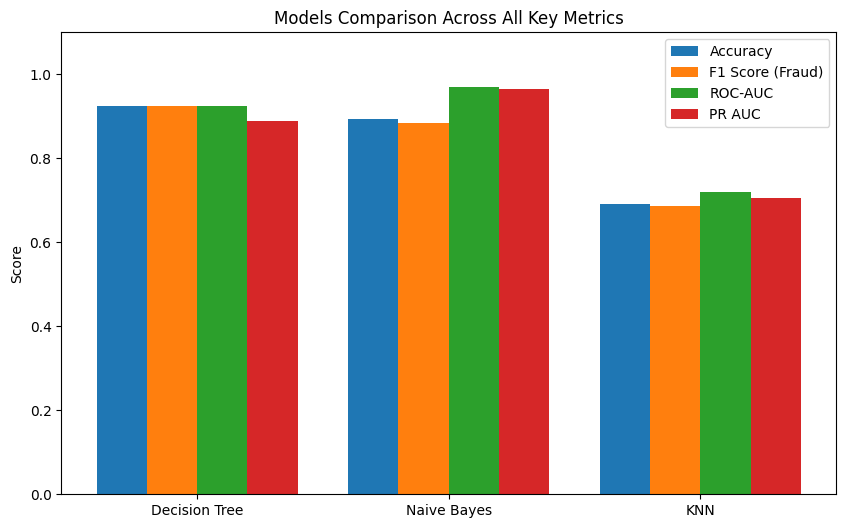

,Accuracy,F1 Score (Fraud),ROC-AUC,PR AUC
Model,,,,
Decision Tree,0.924051,0.924370,0.924085,0.888275
Naive Bayes,0.894515,0.883721,0.969520,0.964816
KNN,0.691983,0.686695,0.720090,0.705583


In [ ]:
def compare_models_simple(
    y_test, y_pred_dt, y_pred_nb, y_pred_knn,
    dt_model, nb_model, knn_model, X_test
):
    """
    Compares Decision Tree, Naive Bayes, and KNN classifiers across Accuracy,
    F1 Score (for fraud class), ROC-AUC, and Precision-Recall AUC. Plots a bar chart and prints a DataFrame summary.
    Dynamically computes AUCs from models.

    Parameters:
        y_test: Ground-truth labels
        y_pred_dt, y_pred_nb, y_pred_knn: Model predictions
        dt_model, nb_model, knn_model: Trained model objects (must support predict_proba)
        X_test: Test features (for predict_proba/AUC calculation)
    """
    models = ['Decision Tree', 'Naive Bayes', 'KNN']
    accuracies = [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_knn)
    ]
    f1_scores = [
        classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_nb, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_knn, output_dict=True)['1']['f1-score']
    ]
    roc_aucs = [
        roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, nb_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])
    ]
    pr_aucs = [
        average_precision_score(y_test, dt_model.predict_proba(X_test)[:, 1]),
        average_precision_score(y_test, nb_model.predict_proba(X_test)[:, 1]),
        average_precision_score(y_test, knn_model.predict_proba(X_test)[:, 1])
    ]

    summary_df = pd.DataFrame({
        'Model': models,
        'Accuracy': accuracies,
        'F1 Score (Fraud)': f1_scores,
        'ROC-AUC': roc_aucs,
        'PR AUC': pr_aucs
    }).set_index('Model')

    print("\nModel Comparison Summary\n")
    print(summary_df)

    plt.figure(figsize=(10,6))
    bar_width = 0.2
    r1 = np.arange(len(models))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]
    r4 = [x + bar_width for x in r3]

    plt.bar(r1, accuracies,        width=bar_width, label='Accuracy')
    plt.bar(r2, f1_scores,         width=bar_width, label='F1 Score (Fraud)')
    plt.bar(r3, roc_aucs,          width=bar_width, label='ROC-AUC')
    plt.bar(r4, pr_aucs,           width=bar_width, label='PR AUC')
    plt.xticks([r + 1.5*bar_width for r in range(len(models))], models)
    plt.ylim(0,1.1)
    plt.ylabel("Score")
    plt.title("Models Comparison Across All Key Metrics")
    plt.legend()
    plt.show()

    return summary_df

compare_models_simple(
    y_test, y_pred_dt, y_pred_nb, y_pred_knn,
    dt_model, nb_model, knn_model, X_test
)